In [214]:
import numpy as np
from numpy import linalg as la

from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

from scipy import interpolate as ip

from scipy.optimize import leastsq, curve_fit

In [2]:
# Q 7.1
A = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3, 3)
print(la.det(A))

1.0


In [3]:
b = np.array([2, 2, -1])
Ainv = la.inv(A)
xyz = Ainv@b
print(f'[x, y, z] = {xyz}')

[x, y, z] = [10. -1. -2.]


In [4]:
prod = A@A.T
if prod.flatten().all == np.identity(3).flatten().all:
    print('A is orthogonal')
else:
    print('A is not orthogonal')

A is not orthogonal


In [5]:
lamda, v = la.eig(A)
print(lamda)

[ 1.         -4.79128785 -0.20871215]


In [6]:
# Q 7.3
def Ey(beta):
    beta = np.deg2rad(beta)
    E_y = np.array([np.cos(beta), 0, -np.sin(beta), 0, 1, 0, np.sin(beta), 0, np.cos(beta)]).reshape(3,3)
    return E_y

def Ez(gamma):
    gamma = np.deg2rad(gamma)
    E_z = np.array([np.cos(gamma), np.sin(gamma), 0, -np.sin(gamma), np.cos(gamma), 0, 0, 0, 1]).reshape(3,3)
    return E_z

E = Ez(180-123) @ Ey(90-27.4) @ Ez(192.25)
print(E)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]


In [7]:
print(la.eigvals(E))
# Rot matrix if last value is 1

[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]


In [8]:
ra = 192.25
dec = 27.4

def r(ra, dec):
    ra = np.deg2rad(ra)
    dec = np.deg2rad(dec)
    x = np.cos(dec) * np.cos(ra)
    y = np.cos(dec) * np.sin(ra)
    z = np.sin(dec)
    return np.array([x, y, z]).reshape(3,1)

v = r(ra, dec)
print(v)
print(la.norm(v))

print('\n', E@v)

[[-0.86760081]
 [-0.1883746 ]
 [ 0.46019978]]
1.0

 [[2.45631360e-17]
 [8.50626821e-17]
 [1.00000000e+00]]


In [227]:
# Q 7.5
a = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
b = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
B = b.reshape(len(b),1)

A = []
for i in a:
    j = len(a)
    while j > 0:
        A.append(i**j)
        j -= 1

n = int(np.sqrt(len(A)))
A = np.array(A).reshape(n,n)

X = la.solve(A, B)
print(X)

[[-4.72443311e-05]
 [ 2.39549403e-03]
 [-5.21636609e-02]
 [ 6.37552288e-01]
 [-4.79490505e+00]
 [ 2.28660622e+01]
 [-6.86092630e+01]
 [ 1.23756868e+02]
 [-1.20531377e+02]
 [ 4.80238940e+01]]


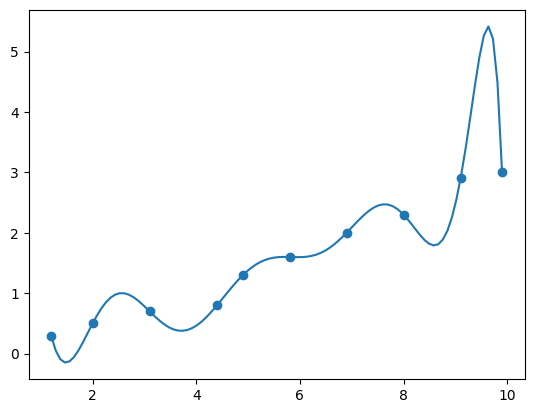

In [228]:
xs = np.linspace(a.min(), a.max(), 100)

def f(x: np.ndarray, X: np.ndarray) -> np.ndarray:
    f = 0
    for i in range(len(X)):
        n = i
        f += X[i] * x**((len(X) - n))
    return f

fig, ax = plt.subplots()
ax.scatter(a, B)
ax.plot(xs, f(xs, X))
plt.show()

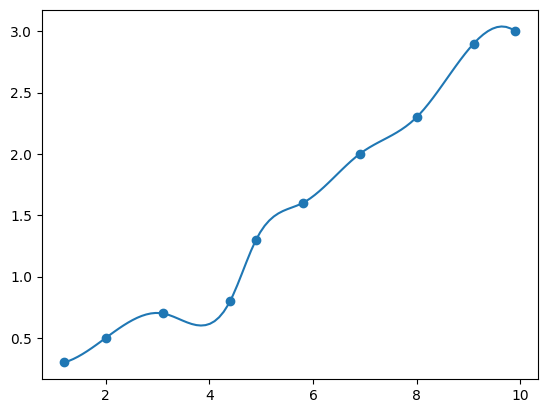

In [229]:
# Q 7.6
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = ip.interp1d(x, y, kind='cubic')

newx = np.linspace(x.min(), x.max(), 100)

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(newx, f(newx))
plt.show()

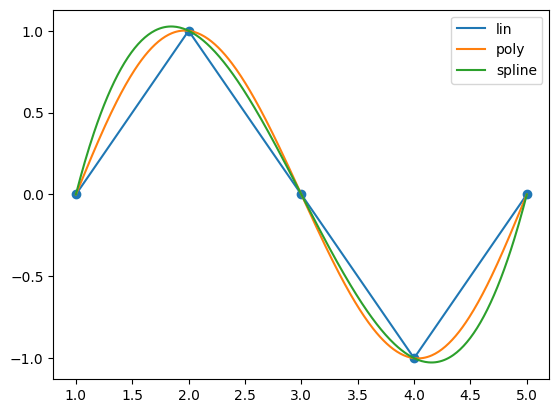

0.19999999999999996


In [230]:
x = np.asarray(list(map(int, input("x-values separated by space: ").split())))
y = np.asarray(list(map(int, input("y-values separated by space: ").split())))

def f(x: np.ndarray, X: np.ndarray) -> np.ndarray:
    f = 0
    for i in range(len(X)):
        n = i
        f += X[i] * x**((len(X) - n))
    return f

class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y

        self.newx = np.linspace(self.x.min(), self.x.max(), (self.x.max() - self.x.min())*100)
        self.f_lin = ip.interp1d(self.x, self.y, kind='linear')
        self.f_poly = ip.interp1d(self.x, self.y, kind='cubic')
        self.cs = CubicSpline(self.x, self.y)

        self.A = []
        for i in self.x:
            j = len(self.x)
            while j > 0:
                self.A.append(i**j)
                j -= 1

        self.n = int(np.sqrt(len(self.A)))
        self.A = np.array(self.A).reshape(self.n,self.n)

        self.X = la.solve(self.A, self.y.reshape(len(self.y),1))

    def plot(self):
        fig, ax = plt.subplots()
        ax.scatter(self.x, self.y)
        ax.plot(self.newx, self.f_lin(self.newx),
                label='lin')
        ax.plot(self.newx, f(self.newx, self.X),
                label='poly')
        ax.plot(self.newx, self.cs(self.newx),
                label='spline')
        plt.legend()
        return plt.show()

    def find_x(self):
        findX = float(input('x-value: '))
        method = input('Method: ')

        if method == 'lin' or 'linear':
            return print(self.f_lin(findX))
        elif method == 'poly' or 'polynomial':
            return print(f(self.newx, findX))
        elif method == 'spline':
            return print(self.cs(findX))
        else:
            return print('There has been an error with the input, please try again.')

interpolation(x,y).plot()
interpolation(x,y).find_x()

In [101]:
# Q 7.7
def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
bilin_IP = bilinearIP(I, 0.2, 0.7)
print(bilin_IP)

2.658


In [231]:
# Q 7.10
data = np.asarray([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
])

d = data[::4]
v = data[1::4]
error_d = data[2::4]
error_v = data[3::4]

[69.93817098 64.13233199]


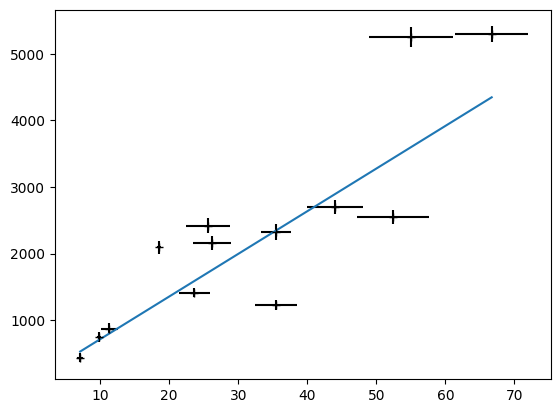

In [233]:
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]
dat = (d, v, error_v)
result = leastsq(residuals, beta_start, args=dat, full_output=1)
(beta, pcov, infodict, errmsg, ier) = result
beta_lsqwei = beta
print(beta_lsqwei)

xspace = np.linspace(d.min(), d.max(), 100)

fig, ax = plt.subplots()
ax.errorbar(d, v,
             xerr=error_d, yerr=error_v,
             fmt='+', color='k')
xmin = d.min(); xmax = d.max()
ymin = model(beta_lsqwei, xmin); ymax = model(beta_lsqwei, xmax)
ax.plot([xmin, xmax], [ymin, ymax])
plt.show()

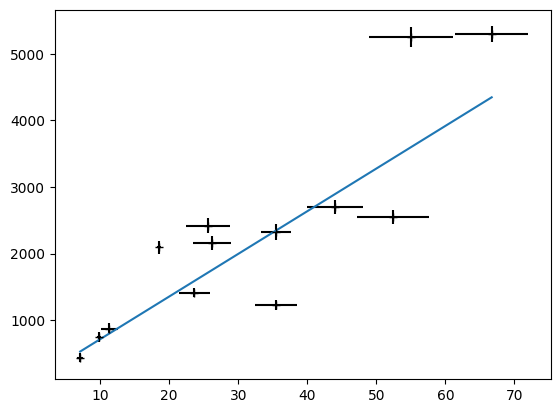

In [234]:
def model(x, beta0, beta1):
    return beta0 + beta1*x

beta, pcov = curve_fit(model, d, v, sigma=error_v, absolute_sigma=True)

X = np.array([d.min(),d.max()])
Y = model(X, beta[0], beta[1])

fig, ax = plt.subplots()
ax.errorbar(d, v,
             xerr=error_d, yerr=error_v,
             fmt='+', color='k')
ax.plot(X, Y)
plt.show()